# Tutorial: Probabilistic Inference of Roles in Memo 
Welcome! 

In this tutorial we will be using [memo](https://github.com/kach/memo) to model how agents infer their role within an institution which determines how they then act.

To achieve this, we will be modelling a situation where each agent starts off unsure which role it is supposed to play, but where all players gradually converge to a shared role assignment over the course of multiple steps by inferring the role assignment that best explains the actions they've taken so far.

## Outline:
1. Basic Game

    1.1 Installing and Importing Dependencies
    1.2 Game Setup
    1.3 Bayesian Inference with Memo
    1.4 Simulating Role Convergence
2. Stateful Extensions

    2.1 Extended Game Setup: Roles, Actions, and Health States
    2.2 Action Policy
    2.3 Updated Inference Model
    2.4 Stats System: Individual Capabilities
    2.5 Transition Dynamics
    2.6 Exploring Different Role Priors
    2.7 Simulation
    2.8 Run First Demo

3. Multi-Factor Experiments
    3.1 Experimental Design
    3.2 Run Full Experiment
    3.3 Visualizing the results
    3.4 Interpreting The Results
    3.5 Overall Conclusions

# 1. Basic Game <a name="basic"></a>
## 1.1 Installing and Importing Dependencies
We start first by installing memo-lang, then importing the relevant packages

In [261]:
# !pip install memo-lang

In [262]:
from memo import memo
import jax
import jax.numpy as np
from enum import IntEnum

## 1.2 Game Setup
We start with a simplified game which just has 3 roles and 3 actions.
### Roles
Each player can adopt one of three roles:
- **Fighter**: Specializes in attacking 
- **Tank**: Specializes in defense 
- **Healer**: Specializes in support 

### Actions
Each turn, players choose one action:
- **Attack**: Deal damage to enemy
- **Defend**: Protect team from enemy attacks
- **Heal**: Restore team health

In [263]:
class Role(IntEnum): Fighter = 0; Tank = 1; Healer = 2
class Action(IntEnum): Attack = 0; Defend = 1; Heal = 2

ROLE_ACTION_PROBS = np.array([
  [0.70, 0.25, 0.05],  # fighter mostly attacks (70% attack, 25% defend, 5% heal)
  [0.25, 0.70, 0.05],  # tank mostly defends (25% attack, 70% defend, 5% heal)
  [0.25, 0.05, 0.70],  # healer mostly heals (25% attack, 5% defend, 70% heal)
])

@jax.jit
def role_policy(role, action):  # role-conditioned action likelihood P(action | role)
    return ROLE_ACTION_PROBS[role, action]

## 1.3 Bayesian Inference with Memo
We now define a memo model where a single observer infers the roles of all players in the team based on each of their actions, starting with a prior over roles. 
### The `memo` Framework

`memo` is a probabilistic programming language that lets us express generative models and perform inference.

**Key concepts**:
- `observer`: The agent doing the reasoning
- `observer: thinks[...]`: The observer's model of how the world works
- `team: assigned(...)`: Sample a value according to some distribution (here, roles)
- `team: chooses(...)`: Sample an action according to a policy
- `observer: observes_that [condition]`: Condition on observed evidence
- `observer[Pr[query]]`: Compute posterior probability of a query

### Our Inference Model

The observer thinks:
1. The team has some role assignment (prior distribution)
2. Each player chooses actions according to their role policy
3. We observe the actual actions taken
4. **Inference**: What's the posterior probability of each role assignment?


In [264]:
@memo
def role_inference[r0 : Role, r1 : Role, r2 : Role](role_prior:... , obs_a0, obs_a1, obs_a2):
    observer: knows(r0, r1, r2) # Push array axis variables into observer's frame
    observer: thinks[
        team: assigned(r0 in Role, r1 in Role, r2 in Role, wpp=get_element(role_prior, r0, r1, r2)), # Assign roles to each player
        team: chooses(a0 in Action, wpp=role_policy(r0, a0)), # Choose player 0's action (a0) according to their role (r0)
        team: chooses(a1 in Action, wpp=role_policy(r1, a1)), # Choose player 1's action (a1) according to their role (r1)
        team: chooses(a2 in Action, wpp=role_policy(r2, a2))  # Choose player 2's action (a2) according to their role (r2)
    ]
    observer: observes_that [team.a0 == obs_a0] # Observe player 0's action
    observer: observes_that [team.a1 == obs_a1] # Observe player 1's action
    observer: observes_that [team.a2 == obs_a2] # Observe player 2's action
    return observer[Pr[r0 == team.r0 and r1 == team.r1 and r2 == team.r2]]

# Due to some of memo's limitations, we also need to introduce a helper function that extracts an element from a (3D) array:
@jax.jit
def get_element(array, i0, i1, i2):
    return array[i0, i1, i2]

With the model defined, we now 
1. Assume a uniform prior over all role assignments (27 possible combinations)
2. Observe the actions taken by each player
3. Compute the posterior probability of each role assignment

We also get the probability distribution over roles for each player by marginalizing out the other players' roles.

In [265]:
role_prior = np.ones((3, 3, 3))
actions = [Action.Attack, Action.Defend, Action.Heal]
role_probs = role_inference(role_prior, *actions, print_table=True)

def marginalize(probs, keepaxis):
    return np.sum(probs, axis=tuple(i for i in range(probs.ndim) if i != keepaxis))

# Print the distribution over roles for each player
print(f"Distribution over roles for player 0: {marginalize(role_probs, 0)}")
print(f"Distribution over roles for player 1: {marginalize(role_probs, 1)}")
print(f"Distribution over roles for player 2: {marginalize(role_probs, 2)}")

+----------+----------+----------+------------------------+
| r0: Role | r1: Role | r2: Role | role_inference         |
+----------+----------+----------+------------------------+
| Fighter  | Fighter  | Fighter  | 0.009114583022892475   |
| Fighter  | Fighter  | Tank     | 0.009114583022892475   |
| Fighter  | Fighter  | Healer   | 0.1276041567325592     |
| Fighter  | Tank     | Fighter  | 0.02552083134651184    |
| Fighter  | Tank     | Tank     | 0.02552083134651184    |
| Fighter  | Tank     | Healer   | 0.35729166865348816    |
| Fighter  | Healer   | Fighter  | 0.0018229165580123663  |
| Fighter  | Healer   | Tank     | 0.0018229165580123663  |
| Fighter  | Healer   | Healer   | 0.02552083134651184    |
| Tank     | Fighter  | Fighter  | 0.003255208721384406   |
| Tank     | Fighter  | Tank     | 0.003255208721384406   |
| Tank     | Fighter  | Healer   | 0.0455729179084301     |
| Tank     | Tank     | Fighter  | 0.009114583022892475   |
| Tank     | Tank     | Tank     | 0.009

The table above gives the observers confidence of the roles that each player is playing, and the distributions above show the marginalized probability of each role for each player.

Suppose the observer knows that there is only one player assigned to each role in the whole team. We can encode this assumption by changing the prior so that it assigns positive probability to only role combinations where all roles differ:

In [266]:
# Create a constrained prior that ensures role uniqueness
i, j, k = np.indices((3, 3, 3))
mask = (i != j) & (i != k) & (j != k)
constrained_prior = mask.astype(np.float32)
# Run role inference and print results
role_probs = role_inference(constrained_prior, *actions, print_table=True)

+----------+----------+----------+------------------------+
| r0: Role | r1: Role | r2: Role | role_inference         |
+----------+----------+----------+------------------------+
| Fighter  | Fighter  | Fighter  | 0.0                    |
| Fighter  | Fighter  | Tank     | 0.0                    |
| Fighter  | Fighter  | Healer   | 0.0                    |
| Fighter  | Tank     | Fighter  | 0.0                    |
| Fighter  | Tank     | Tank     | 0.0                    |
| Fighter  | Tank     | Healer   | 0.8553615808486938     |
| Fighter  | Healer   | Fighter  | 0.0                    |
| Fighter  | Healer   | Tank     | 0.0043640900403261185  |
| Fighter  | Healer   | Healer   | 0.0                    |
| Tank     | Fighter  | Fighter  | 0.0                    |
| Tank     | Fighter  | Tank     | 0.0                    |
| Tank     | Fighter  | Healer   | 0.10910224914550781    |
| Tank     | Tank     | Fighter  | 0.0                    |
| Tank     | Tank     | Tank     | 0.0  

As you can see, there are now only 6 possible role allocations!

Feel free to play with the interactive visualization below to understand how the observer's predictions changes depending on the observed actions in one round and whether the observer knows that roles must be unique.


In [267]:
input_1 = 'Attack'

In [268]:
input_2 = 'Defend'

In [269]:
input_3 = 'Heal'

In [270]:
is_role_unique = False

In [271]:
import matplotlib.pyplot as plt

def parse_input(inp):
    if inp == "Attack":
        return 0
    elif inp == "Defend":
        return 1
    elif inp == "Heal":
        return 2
    else:
        return -1

if is_role_unique:
    i, j, k = np.indices((3, 3, 3))
    mask = (i != j) & (i != k) & (j != k)
    role_prior = mask.astype(np.float32)
else:
    role_prior = np.ones((3, 3, 3))

actions = [Action(parse_input(input_1)), Action(parse_input(input_2)), Action(parse_input(input_3))]
role_probs = role_inference(role_prior, *actions, print_table=False)

# Get the configuration with highest probability
max_idx = np.unravel_index(np.argmax(role_probs), role_probs.shape)
max_prob = role_probs[max_idx]

# Get role names
role_names = [Role(i).name for i in max_idx]

# Optional: Show top 5 configurations
print("\n📊 Top 5 Role Configurations:")
flat_probs = role_probs.flatten()
top_5_indices = np.argsort(flat_probs)[-5:][::-1]

for rank, flat_idx in enumerate(top_5_indices, 1):
    idx = np.unravel_index(flat_idx, role_probs.shape)
    roles = [Role(i).name for i in idx]
    prob = role_probs[idx]
    print(f"{rank}. {roles[0]:8s} | {roles[1]:8s} | {roles[2]:8s} : {prob:.1%}")

print("\n🎯 Most Likely Roles:")
for player, role_idx in enumerate(max_idx):
    print(f"   Player {player}: {Role(role_idx).name} ({max_prob:.1%})")


📊 Top 5 Role Configurations:
1. Fighter  | Tank     | Healer   : 35.7%
2. Healer   | Tank     | Healer   : 12.8%
3. Tank     | Tank     | Healer   : 12.8%
4. Fighter  | Fighter  | Healer   : 12.8%
5. Healer   | Fighter  | Healer   : 4.6%

🎯 Most Likely Roles:
   Player 0: Fighter (35.7%)
   Player 1: Tank (35.7%)
   Player 2: Healer (35.7%)


## 1.4 Simulating Role Convergence
Now we extend this to multiple time steps. Each player starts off unsure which role it is supposed to play, but all players gradually converge to a shared role assignment over the course of multiple steps by inferring the role assignment that best explains the actions they've taken so far. At every step, each agent: 
1. Samples a role according to its current belief distribution over its own role 
2. Takes an action according to the policy for that role 
3. Updates its belief about the role assignments given the actions taken by all players. 

For simplicity, we'll assume that all agents start with a common prior, so that we don't have to perform separate belief updates for each agent (a common prior leads to a common posterior under full observability).

Since memo doesn't readily support sampling or for-loops, we will write this part using regular Python code:

In [272]:
import random

def simulate_role_convergence(n_steps, role_prior):
  role_probs = role_prior
  # Preallocate arrays for histories
  role_history = np.zeros((n_steps, 3), dtype=np.int32)
  action_history = np.zeros((n_steps, 3), dtype=np.int32)
  role_prob_history = np.zeros((n_steps, 3, 3, 3), dtype=np.float32)
  for t in range(n_steps):
    # Sample a role for each agent according to the marginal distribution over their role
    roles = [random.choices([0, 1, 2], weights=marginalize(role_probs, i))[0] for i in range(3)]
    role_history = role_history.at[t].set(np.array(roles)) # Store roles

    # Sample an action for each agent according to the role policy
    actions = [random.choices([0, 1, 2], weights=ROLE_ACTION_PROBS[r, :])[0] for r in roles]
    action_history = action_history.at[t].set(np.array(actions)) # Store actions

    # Update (common) beliefs about role assignments via role inference
    role_probs = role_inference(role_probs, *actions)
    role_prob_history = role_prob_history.at[t].set(role_probs) # Store updated probabilities

  return role_history, action_history, role_prob_history


In [273]:
random_seed = 46

In [274]:
time_steps = 20

In [275]:
random.seed(random_seed)
n_steps = time_steps
role_prior = np.ones((3, 3, 3))
role_history, action_history, role_prob_history = simulate_role_convergence(n_steps, role_prior)

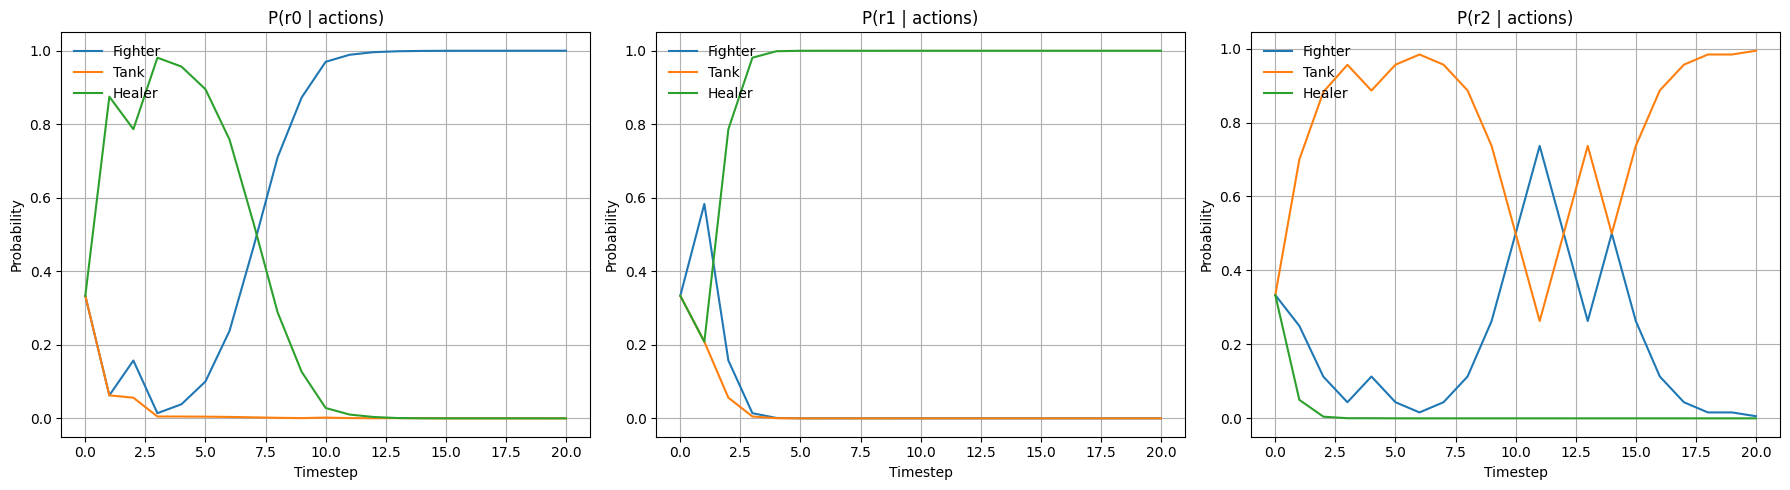

In [276]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots, one for each player
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i in range(3): # Iterate over players
    # Calculate marginal probabilities for the current player at each timestep
    player_role_probs = [marginalize(role_prob_history[t], i) for t in range(n_steps)]
    # Add the initial timestep's probabilities
    player_role_probs.insert(0, marginalize(role_prior / role_prior.sum(), i))
    player_role_probs = np.array(player_role_probs)

    # Plot the evolution of role probabilities for the current player
    for role in Role:
        axes[i].plot(range(n_steps + 1), player_role_probs[:, role], label=role.name)

    axes[i].set_title(f'P(r{i} | actions)')
    axes[i].set_xlabel('Timestep')
    axes[i].set_ylabel('Probability')
    axes[i].legend(frameon=False, loc='upper left')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# 2.  Stateful Extensions
Thus far, we have built a basic model of decentralized role coordination via iterative updating of each player's beliefs. We now extend the game by introducing statefulness with `team_health` and `enemy_health`. We also introduce `player_stats` of `str`, `def` and `sup` that affect which roles each player is most suited to.

## 2.1 Extended Game Setup: Roles, Actions, and Health States

### Roles
Each player can adopt one of three roles:
- **Fighter**: Specializes in attacking (high STR)
- **Tank**: Specializes in defense (high DEF)
- **Healer**: Specializes in support (high SUP)

### Actions
Each turn, players choose one action:
- **Attack**: Deal damage to enemy
- **Defend**: Protect team from enemy attacks
- **Heal**: Restore team health

### Health States
Both enemy and team health progress through 5 states:
- **DEAD** (0) → **LOW** (1) → **MEDIUM** (2) → **HIGH** (3) → **FULL** (4)

**Victory condition**: Reduce enemy health to DEAD  
**Loss condition**: Team health drops to DEAD  
**Draw**: Max timesteps reached without resolution

In [277]:
class Role(IntEnum): Fighter = 0; Tank = 1; Healer = 2;
class Action(IntEnum): Attack = 0; Defend = 1; Heal = 2;
class EnemyHealth(IntEnum): DEAD = 0;LOW = 1; MEDIUM = 2;HIGH = 3; FULL = 4;
class TeamHealth(IntEnum): DEAD = 0;LOW = 1; MEDIUM = 2;HIGH = 3; FULL = 4;

## 2.2 Action Policy
In the basic game, there are only `3` possible actions for `3` roles, resulting in `9` different outcomes. 
In this extension, there are `5` states for both the enemy and team health, resulting in `3*3*5*5 = 255` different outcomes  

We have setup roles that adapt their behavior based on both enemy and team health. The probabilities are set based on the assumptions: 
- As team health decreases, a team should defend or heal more.
- As an enemy gets weaker it does less damage to a team, so a team would need less defending.

In [278]:
ROLE_ACTION_STATE_PROBS_V1 = np.array([
    # Fighter probabilities [enemy_health, team_health, action]
    # Base: Attack 0.90, adapts based on game state
    # - Higher attack when enemy is LOW (easier target) or team is HIGH (confident)
    # - Lower attack when enemy is HIGH (harder target) or team is LOW (more cautious)
    [
        # enemy DEAD - random regardless of team health
        [[0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34]],
        # enemy LOW, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04]],
        # enemy MEDIUM, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.60, 0.25, 0.15], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04]],
        # enemy HIGH, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.50, 0.30, 0.20], [0.70, 0.18, 0.12], [0.90, 0.06, 0.04], [0.90, 0.06, 0.04]],
        # enemy FULL, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.40, 0.35, 0.25], [0.60, 0.25, 0.15], [0.80, 0.12, 0.08], [0.90, 0.06, 0.04]],
    ],
    # Tank probabilities [enemy_health, team_health, action]
    # Base: Defend 0.90, adapts based on game state
    # - Higher defend when team is LOW (protect team) or enemy is HIGH (more threatening)
    # - Lower defend when team is HIGH (less protection needed) or enemy is LOW (less threatening)
    [
        # enemy DEAD - random regardless of team health
        [[0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34]],
        # enemy LOW, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.10, 0.75, 0.15], [0.15, 0.70, 0.15], [0.20, 0.65, 0.15], [0.25, 0.60, 0.15]],
        # enemy MEDIUM, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.08, 0.82, 0.10], [0.10, 0.80, 0.10], [0.15, 0.75, 0.10], [0.20, 0.70, 0.10]],
        # enemy HIGH, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.05, 0.88, 0.07], [0.06, 0.86, 0.08], [0.08, 0.84, 0.08], [0.10, 0.82, 0.08]],
        # enemy FULL, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.04, 0.90, 0.06], [0.04, 0.88, 0.08], [0.06, 0.86, 0.08], [0.08, 0.84, 0.08]],
    ],
    # Healer probabilities [enemy_health, team_health, action]
    # Base: Heal 0.90, adapts based on game state
    # - Higher heal when team is LOW (team needs healing)
    # - Lower heal when team is HIGH (team doesn't need healing)
    # - Consistent across enemy health (always focused on healing regardless of enemy state)
    [
        # enemy DEAD - random regardless of team health
        [[0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34], [0.33, 0.33, 0.34]],
        # enemy LOW, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.05, 0.05, 0.90], [0.08, 0.07, 0.85], [0.10, 0.10, 0.80], [0.15, 0.15, 0.70]],
        # enemy MEDIUM, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.05, 0.05, 0.90], [0.08, 0.07, 0.85], [0.10, 0.10, 0.80], [0.15, 0.15, 0.70]],
        # enemy HIGH, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.05, 0.05, 0.90], [0.08, 0.07, 0.85], [0.10, 0.10, 0.80], [0.15, 0.15, 0.70]],
        # enemy FULL, team: [DEAD, LOW, MEDIUM, HIGH, FULL]
        [[0.33, 0.33, 0.34], [0.05, 0.05, 0.90], [0.08, 0.07, 0.85], [0.10, 0.10, 0.80], [0.15, 0.15, 0.70]],
    ],
])

@jax.jit
def role_policy_v1(role, action, enemy_health, team_health):
    """Get probability of action given role and game state."""
    return ROLE_ACTION_STATE_PROBS_V1[role, enemy_health, team_health, action]

## 2.3 Updated Inference Model
With the new policies defined, we can now incorporate states into our inference model 

In [279]:
@memo
def role_inference_v1[r0: Role, r1: Role, r2: Role](
    role_prior: ..., obs_a0, obs_a1, obs_a2, enemy_health, team_health
):
    """
    Infer role probabilities given observed actions and game state.
    
    Args:
        role_prior: 3x3x3 array of prior probabilities P(r0, r1, r2)
        obs_a0, obs_a1, obs_a2: Observed actions for players 0, 1, 2
        enemy_health: Current enemy health state
        team_health: Current team health state
    
    Returns:
        3x3x3 array of posterior probabilities P(r0, r1, r2 | actions, state)
    """
    observer: knows(r0, r1, r2)  # Push array indices into observer's frame
    
    # Observer's generative model
    observer: thinks[
        # Sample role assignment according to prior
        team: assigned(
            r0 in Role, r1 in Role, r2 in Role,
            wpp=get_element(role_prior, r0, r1, r2)
        ),
        # Each player chooses action according to their role policy
        team: chooses(a0 in Action, wpp=role_policy_v1(r0, a0, enemy_health, team_health)),
        team: chooses(a1 in Action, wpp=role_policy_v1(r1, a1, enemy_health, team_health)),
        team: chooses(a2 in Action, wpp=role_policy_v1(r2, a2, enemy_health, team_health))
    ]
    
    # Condition on observed actions
    observer: observes_that [team.a0 == obs_a0]
    observer: observes_that [team.a1 == obs_a1]
    observer: observes_that [team.a2 == obs_a2]
    
    # Return posterior probability of this role assignment
    return observer[Pr[r0 == team.r0 and r1 == team.r1 and r2 == team.r2]]

# Due to some of memo's limitations, we also need to introduce a helper function that extracts an element from a (3D) array:
@jax.jit
def get_element(array, i0, i1, i2):
    return array[i0, i1, i2]

## 2.4 Stats System: Individual Capabilities

Each player has three stats that sum to 1.0:
- **STR** (Strength): Boosts attack effectiveness
- **DEF** (Defense): Boosts defend effectiveness
- **SUP** (Support): Boosts heal effectiveness

**Example**:
- Player with [0.7, 0.2, 0.1] is naturally suited to be a Fighter
- Player with [0.1, 0.7, 0.2] is naturally suited to be a Tank
- Player with [0.2, 0.1, 0.7] is naturally suited to be a Healer

Stats affect the **transition probabilities**: a team with high total STR deals more damage! We will be modelling 3 different stat distributions, where each player has `balanced` stats (all 1/3), `extreme` stats (0.8+ in one stat) and just `random` stats. 

In [280]:
def generate_player_stats(player_id, seed=42, mode='random'):
    """
    Generate player stats [STR, DEF, SUP] that sum to 1.0.
    
    Args:
        player_id: Unique identifier for reproducibility
        seed: Random seed
        mode: 'random' (Dirichlet), 'balanced' (0.33 each), 'specialist' (0.8+ in one stat)
    """
    random.seed(seed + player_id)
    
    if mode == 'balanced':
        return np.array([1/3, 1/3, 1/3])
    elif mode == 'specialist':
        # Put 0.8-0.9 in one stat, split remainder
        dominant_idx = player_id % 3
        dominant_val = 0.8 + random.random() * 0.15  # 0.8 to 0.95
        remainder = 1.0 - dominant_val
        other_val = remainder / 2
        stats = [other_val, other_val, other_val]
        stats[dominant_idx] = dominant_val
        return np.array(stats)
    else:  # 'random' - Dirichlet distribution
        alpha = [1.0, 1.0, 1.0]
        raw_stats = [random.gammavariate(a, 1.0) for a in alpha]
        total = sum(raw_stats)
        return np.array([s / total for s in raw_stats])

## 2.5 Transition Dynamics
At each turn, we decide whether the health state of the enemy and team should increase, stay the same or decrease. 
To do this, we count the number of attacks, defends and heals and also sum up the STR of attackers, DEF of defenders and SUP of healers.  We also add a `difficulty` parameter to make it easy to simulate enemies with differing difficulties.

The transition function implements the following logic:

**Enemy Health Transition:**
- Base damage probability (0.3-0.7) depends on total STR of attacking players
- Enemy at lower health is easier to damage (state-dependent multiplier)
- Enemy has small chance (5%) to heal each turn

**Team Health Transition:**
- Enemy deals damage based on its health level and difficulty multiplier
- Defenders mitigate damage based on their total DEF stat
- Healers restore health based on their total SUP stat
- Team at LOW health (=1) takes amplified damage (1.2x)

**Parameters:**
- `enemy_health`, `team_health`: Current health states (0-4)
- `actions`: Array of 3 actions, one per player
- `stats`: (3, 3) array where row i contains [STR, DEF, SUP] for player i
- `difficulty`: Enemy strength multiplier (0.5=easy, 1.0=normal, 1.5=hard)
- `key`: JAX random key for stochastic transitions


In [281]:
import jax.random as jrandom

@jax.jit
def transition(enemy_health, team_health, actions, stats, difficulty, key):
    """
    Compute next health states based on actions and stats.
    
    Args:
        enemy_health: Current enemy health (0-4)
        team_health: Current team health (0-4)
        actions: Array of 3 actions [player0_action, player1_action, player2_action]
        stats: Array of shape (3, 3) - each row is [STR, DEF, SUP] for a player
        difficulty: Enemy difficulty multiplier (0.5=easy, 1.0=normal, 1.5=hard)
        key: JAX random key
        
    Returns:
        next_enemy_health, next_team_health
    """
    # Split random key for enemy and team transitions
    key_enemy, key_team = jrandom.split(key)
    
    # Count actions and compute weighted sums
    attack_mask = (actions == Action.Attack).astype(np.float32)
    defend_mask = (actions == Action.Defend).astype(np.float32)
    heal_mask = (actions == Action.Heal).astype(np.float32)
    
    # Sum stats for each action type
    total_attack_str = np.sum(attack_mask * stats[:, 0])  # STR of attackers
    total_defend_def = np.sum(defend_mask * stats[:, 1])  # DEF of defenders
    total_heal_sup = np.sum(heal_mask * stats[:, 2])     # SUP of healers
    
    # ========== ENEMY HEALTH TRANSITION ==========
    # Base enemy damage taken depends on number of attacks and total STR
    # More attacks + higher STR = more likely to decrease enemy health
    
    # Probability enemy health decreases (gets damaged)
    base_enemy_damage_prob = 0.3 + (total_attack_str * 0.4)  # 0.3-0.7 range
    enemy_damage_prob = np.clip(base_enemy_damage_prob, 0.1, 0.9)
    
    # Enemy at lower health is easier to damage
    state_multiplier = 1.0 + 0.1 * (4 - enemy_health)  # 1.0-1.4x
    enemy_damage_prob = np.clip(enemy_damage_prob * state_multiplier, 0.0, 1.0)
    
    # Compute transition probabilities: [decrease, stay, increase]
    # Enemy rarely heals unless at DEAD (use JAX where for JIT compatibility)
    enemy_heal_prob = np.where(enemy_health > 0, 0.05, 0.0)
    enemy_stay_prob = 1.0 - enemy_damage_prob - enemy_heal_prob
    
    enemy_trans_probs = np.array([enemy_damage_prob, enemy_stay_prob, enemy_heal_prob])
    enemy_trans_probs = enemy_trans_probs / enemy_trans_probs.sum()  # Normalize
    
    # Sample transition
    enemy_delta = jrandom.choice(key_enemy, np.array([-1, 0, 1]), p=enemy_trans_probs)
    next_enemy_health = np.clip(enemy_health + enemy_delta, 0, 4)
    
    # ========== TEAM HEALTH TRANSITION ==========
    # Team health affected by:
    # 1. Enemy attacks (damage) - based on enemy health and difficulty
    # 2. Defend actions (mitigation) - based on total DEF
    # 3. Heal actions (recovery) - based on total SUP
    
    # Enemy attack strength (higher enemy health = stronger attacks)
    enemy_attack_base = np.where(enemy_health > 0, 0.4, 0.0)
    enemy_attack_str = enemy_attack_base * (1.0 + 0.15 * enemy_health) * difficulty
    
    # Defense mitigation (defenders reduce damage)
    defense_mitigation = total_defend_def * 0.5  # DEF reduces damage
    net_damage_prob = np.clip(enemy_attack_str - defense_mitigation, 0.0, 1.0)
    
    # Healing effectiveness
    heal_prob = total_heal_sup * 0.6  # SUP increases healing
    heal_prob = np.clip(heal_prob, 0.0, 0.9)
    
    # When team is at low health, damage is more critical (JAX-compatible conditional)
    damage_multiplier = np.where(team_health == 1, 1.2, 1.0)
    net_damage_prob = net_damage_prob * damage_multiplier
    
    # Compute team transition probabilities
    # Healing and damage compete
    stay_prob = 1.0 - net_damage_prob - heal_prob
    stay_prob = np.maximum(stay_prob, 0.0)
    
    # Normalize
    total_prob = net_damage_prob + stay_prob + heal_prob
    team_trans_probs = np.array([net_damage_prob, stay_prob, heal_prob]) / total_prob
    
    # Sample transition
    team_delta = jrandom.choice(key_team, np.array([-1, 0, 1]), p=team_trans_probs)
    next_team_health = np.clip(team_health + team_delta, 0, 4)
    
    return next_enemy_health, next_team_health

## 2.6 Exploring Different Role Priors
The prior distribution P(roles) encodes initial beliefs about role assignments.

We'll implement three types:
1. **Uniform**: All 27 assignments equally likely (no preferences)
2. **Utility-based (unconstrained)**: Prefer assignments where players match their best stats (allows duplicates)
3. **Utility-based (constrained)**: Same but enforce unique roles (only 6 valid assignments)


Prior comparison for specialist team:
Uniform prior: All 27 assignments have prob 0.0370

Unconstrained utility prior (top 3):
  (Fighter, Tank, Healer): 0.2151
  (Fighter, Tank, Tank): 0.0791
  (Fighter, Fighter, Healer): 0.0791

Constrained utility prior (all 6):
  (Fighter, Tank, Healer): 0.7087
  (Tank, Fighter, Healer): 0.0959
  (Fighter, Healer, Tank): 0.0785
  (Healer, Tank, Fighter): 0.0643
  (Healer, Fighter, Tank): 0.0289
  (Tank, Healer, Fighter): 0.0237


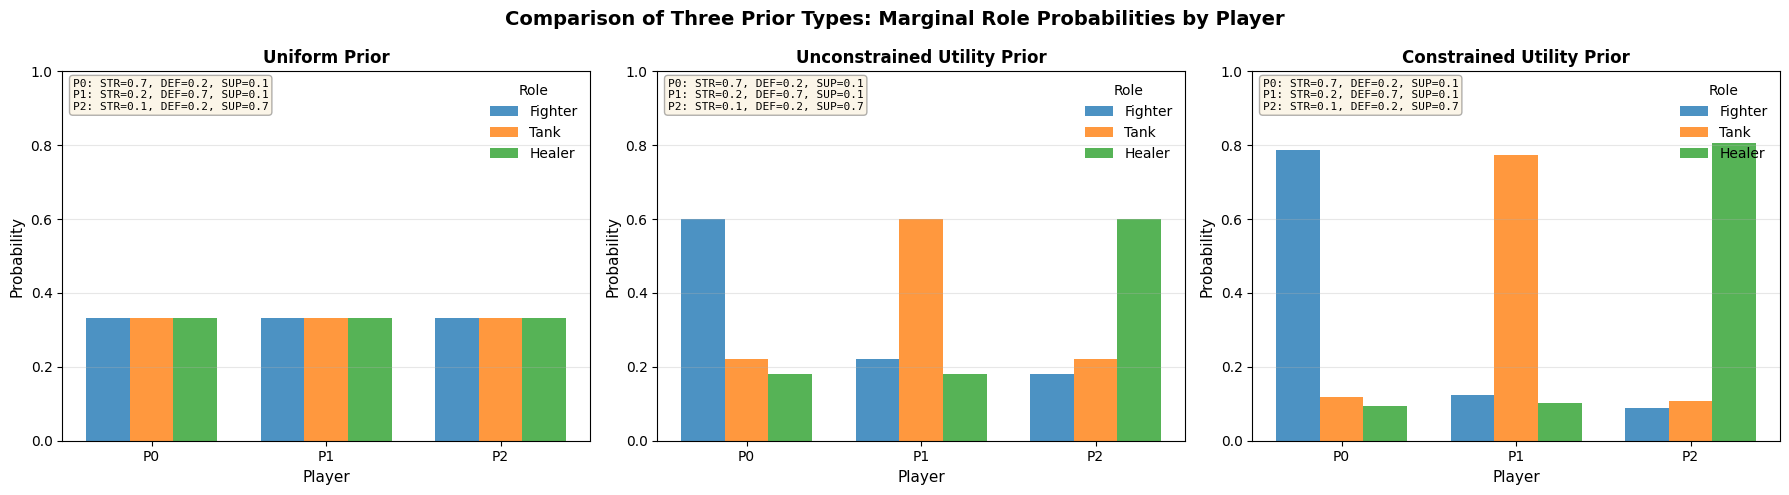

In [282]:
import numpy as onp

def uniform_prior_v1():
    """All role assignments equally likely."""
    prior = np.ones((3, 3, 3))
    return prior / np.sum(prior)

def utility_based_prior_v1(player_stats_list, temperature=0.5, constrained=False):
    """
    Create role prior based on player stats.
    
    Args:
        player_stats_list: List of 3 arrays, each [STR, DEF, SUP]
        temperature: Higher = flatter distribution (more uncertainty)
        constrained: If True, enforce unique roles (only 6 valid assignments)
    
    Returns:
        prior: 3x3x3 array where prior[r0, r1, r2] = P(player0=r0, player1=r1, player2=r2)
    """
    prior = np.zeros((3, 3, 3))
    
    for r0 in range(3):
        for r1 in range(3):
            for r2 in range(3):
                # Check uniqueness constraint if needed
                if constrained and len({r0, r1, r2}) != 3:
                    continue  # Skip duplicate role assignments
                
                # Utility: how well each player fits their assigned role
                u0 = player_stats_list[0][r0]  # Player 0's stat for role r0
                u1 = player_stats_list[1][r1]  # Player 1's stat for role r1
                u2 = player_stats_list[2][r2]  # Player 2's stat for role r2
                
                total_utility = u0 + u1 + u2
                utility = np.exp(total_utility / temperature)
                prior = prior.at[r0, r1, r2].set(utility)
    
    # Normalize
    return prior / np.sum(prior)

# Example: Compare priors
example_stats = [
    np.array([0.7, 0.2, 0.1]),  # Player 0: Strong fighter
    np.array([0.2, 0.7, 0.1]),  # Player 1: Strong tank
    np.array([0.1, 0.2, 0.7]),  # Player 2: Strong healer
]

uniform = uniform_prior_v1()
utility_uncon = utility_based_prior_v1(example_stats, temperature=0.5, constrained=False)
utility_con = utility_based_prior_v1(example_stats, temperature=0.5, constrained=True)

print("\nPrior comparison for specialist team:")
print(f"Uniform prior: All 27 assignments have prob {float(uniform[0,0,0]):.4f}")
print(f"\nUnconstrained utility prior (top 3):")
flat = [(r0,r1,r2, float(utility_uncon[r0,r1,r2])) for r0 in range(3) for r1 in range(3) for r2 in range(3)]
flat.sort(key=lambda x: x[3], reverse=True)
for r0,r1,r2,p in flat[:3]:
    print(f"  ({Role(r0).name}, {Role(r1).name}, {Role(r2).name}): {p:.4f}")

print(f"\nConstrained utility prior (all 6):")
flat_con = [(r0,r1,r2, float(utility_con[r0,r1,r2])) for r0 in range(3) for r1 in range(3) for r2 in range(3) if utility_con[r0,r1,r2] > 0]
flat_con.sort(key=lambda x: x[3], reverse=True)
for r0,r1,r2,p in flat_con:
    print(f"  ({Role(r0).name}, {Role(r1).name}, {Role(r2).name}): {p:.4f}")

# Visualize the three different priors
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

priors = [
    (uniform, 'Uniform Prior'),
    (utility_uncon, 'Unconstrained Utility Prior'),
    (utility_con, 'Constrained Utility Prior')
]

for ax_idx, (prior, title) in enumerate(priors):
    ax = axes[ax_idx]
    
    # Extract marginal probabilities for each player
    marginals = []
    for player in range(3):
        marginal = marginalize(prior, player)
        marginals.append(marginal)
    
    # Plot as grouped bar chart
    x = onp.arange(3)  # Players 0, 1, 2
    width = 0.25
    
    for role_idx, role in enumerate(Role):
        role_probs = [marginals[player][role_idx] for player in range(3)]
        ax.bar(x + (role_idx - 1) * width, role_probs, width, 
               label=role.name, alpha=0.8)
    
    ax.set_xlabel('Player', fontsize=11)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'P{i}' for i in range(3)])
    ax.legend(title='Role', frameon=False)
    ax.set_ylim([0, 1.0])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add player stats as text
    stats_text = '\n'.join([f'P{i}: STR={example_stats[i][0]:.1f}, DEF={example_stats[i][1]:.1f}, SUP={example_stats[i][2]:.1f}' 
                           for i in range(3)])
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=8, verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Comparison of Three Prior Types: Marginal Role Probabilities by Player', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.7 Simulation 
Now putting it all together, we simulate a full game where agents infer roles over time

In [283]:
def marginalize(probs, keepaxis):
    """Extract marginal probability for a single player."""
    return np.sum(probs, axis=tuple(i for i in range(probs.ndim) if i != keepaxis))

def simulate_game_v1(
    n_steps,
    player_stats,
    role_prior,
    initial_enemy_health=EnemyHealth.FULL,
    initial_team_health=TeamHealth.FULL,
    difficulty=1.0,
    seed=42
):
    """
    Simulate the role coordination game.
    
    Args:
        n_steps: Maximum number of timesteps
        player_stats: List of 3 stat arrays
        role_prior: 3x3x3 prior distribution
        initial_enemy_health: Starting enemy health
        initial_team_health: Starting team health
        difficulty: Boss difficulty (0.7=easy, 1.0=normal, 1.3=hard)
        seed: Random seed
    
    Returns:
        Dictionary with:
        - role_history: [T x 3] sampled roles
        - action_history: [T x 3] sampled actions
        - role_prob_history: [T x 3 x 3 x 3] role beliefs
        - enemy_health_history: [T+1] enemy health states
        - team_health_history: [T+1] team health states
        - n_steps: Actual steps taken
        - outcome: 'WIN', 'LOSE', or 'DRAW'
    """
    random.seed(seed)
    key = jax.random.PRNGKey(seed)
    
    # Initialize
    role_probs = role_prior
    enemy_health = initial_enemy_health
    team_health = initial_team_health
    
    # History arrays
    role_history = []
    action_history = []
    role_prob_history = []
    enemy_health_history = [enemy_health]
    team_health_history = [team_health]
    
    for t in range(n_steps):
        # Sample roles from marginal beliefs
        roles = [random.choices([0,1,2], weights=marginalize(role_probs, i))[0] for i in range(3)]
        role_history.append(roles)
        
        # Sample actions from role policies
        actions = [
            random.choices([0,1,2], weights=ROLE_ACTION_STATE_PROBS_V1[r, enemy_health, team_health, :])[0]
            for r in roles
        ]
        action_history.append(actions)
        
        # Update beliefs via Bayesian inference
        role_probs = role_inference_v1(
            role_probs, *actions,
            enemy_health=enemy_health,
            team_health=team_health
        )
        role_prob_history.append(role_probs)
        
        # Update game state with difficulty
        key, subkey = jax.random.split(key)
        stats_array = np.array(player_stats)
        enemy_health, team_health = transition(
            enemy_health, team_health, np.array(actions), stats_array, difficulty=difficulty, key=subkey
        )
        
        enemy_health_history.append(enemy_health)
        team_health_history.append(team_health)
        
        # Check termination
        if enemy_health == EnemyHealth.DEAD:
            outcome = "WIN"
            break
        elif team_health == TeamHealth.DEAD:
            outcome = "LOSE"
            break
    else:
        outcome = "DRAW"
    
    return {
        'role_history': np.array(role_history),
        'action_history': np.array(action_history),
        'role_prob_history': np.array(role_prob_history),
        'enemy_health_history': np.array(enemy_health_history),
        'team_health_history': np.array(team_health_history),
        'n_steps': len(role_history),
        'outcome': outcome
    }

## 2.8 Run First Demo
Let's run a single game and visualize what happens!

In [284]:
demo_seed = 5

In [285]:
# Generate player stats
DEMO_SEED = demo_seed
demo_stats = [generate_player_stats(i, seed=DEMO_SEED, mode='specialist') for i in range(3)]

print("DEMO GAME: Player Stats")
print("="*50)
for i, stats in enumerate(demo_stats):
    best_role = Role(int(np.argmax(stats))).name
    print(f"Player {i}: STR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}")
    print(f"  → Best suited for: {best_role}")

# Create utility-based prior (unconstrained)
demo_prior = utility_based_prior_v1(demo_stats, temperature=0.5, constrained=False)

# Run simulation
print("\nRunning simulation...")
result = simulate_game_v1(
    n_steps=20,
    player_stats=demo_stats,
    role_prior=demo_prior,
    difficulty=1,
    seed=DEMO_SEED
)

print(f"\nResult: {result['outcome']}")
print(f"Duration: {result['n_steps']} steps")
print(f"Final Enemy Health: {EnemyHealth(int(result['enemy_health_history'][-1])).name}")
print(f"Final Team Health: {TeamHealth(int(result['team_health_history'][-1])).name}")

DEMO GAME: Player Stats
Player 0: STR=0.89, DEF=0.05, SUP=0.05
  → Best suited for: Fighter
Player 1: STR=0.04, DEF=0.92, SUP=0.04
  → Best suited for: Tank
Player 2: STR=0.08, DEF=0.08, SUP=0.85
  → Best suited for: Healer

Running simulation...

Result: WIN
Duration: 5 steps
Final Enemy Health: DEAD
Final Team Health: HIGH


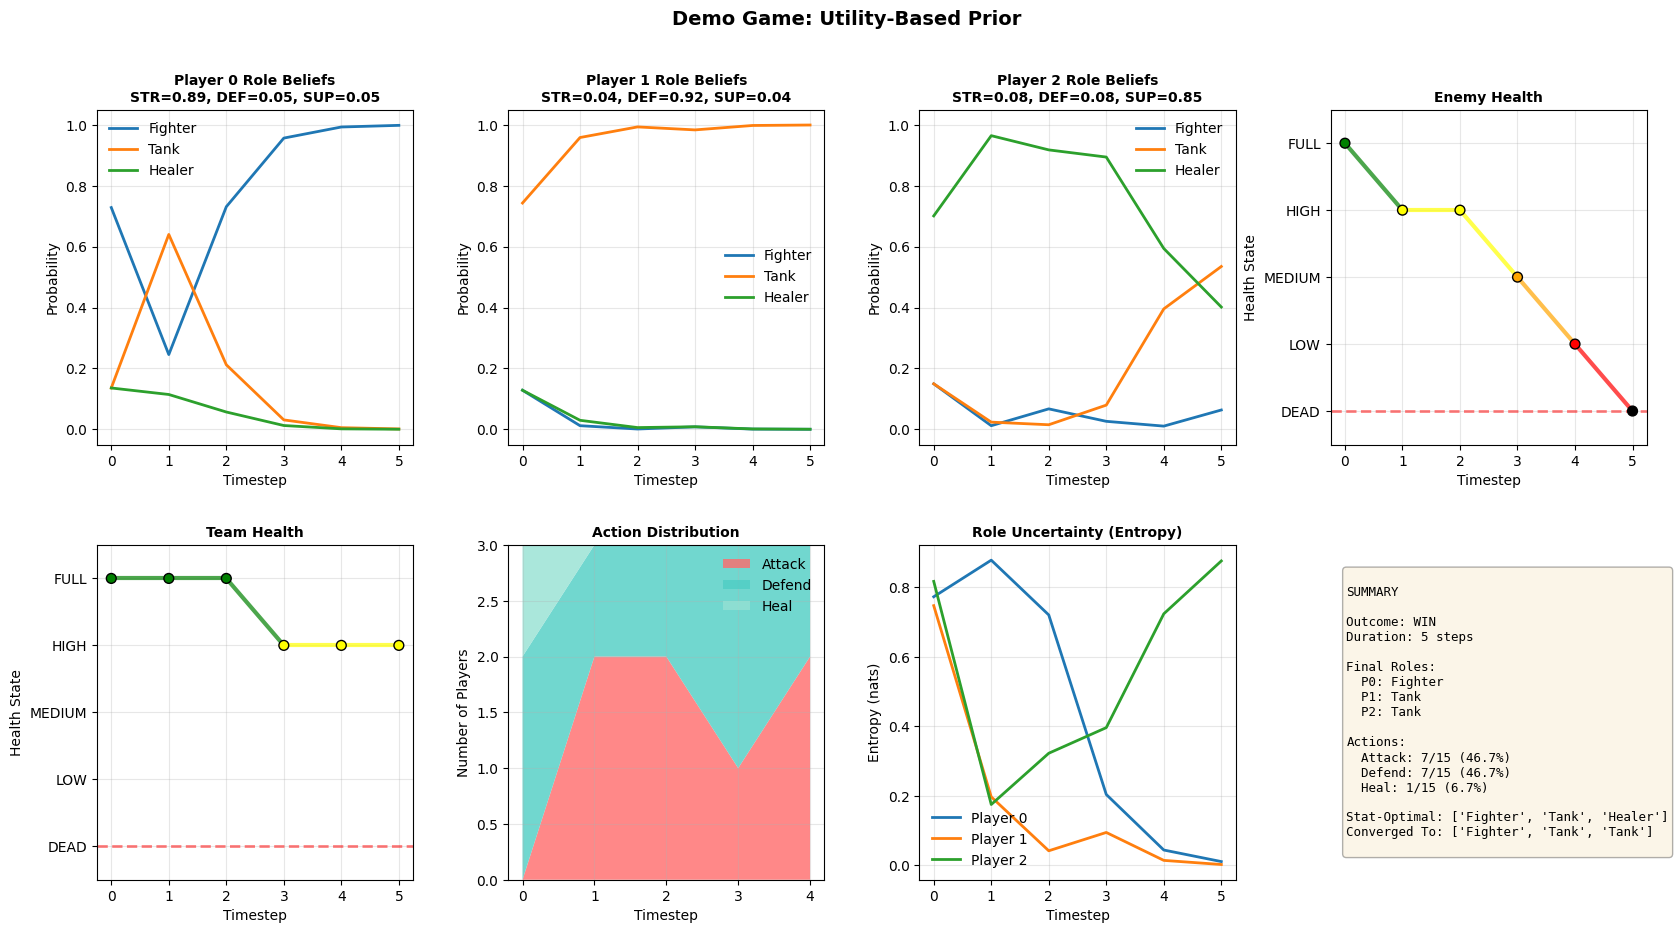

In [286]:
from scipy.stats import entropy

def visualize_game_result(result, player_stats, prior, title="Game Result"):
    """Create comprehensive visualization of game result."""
    fig = plt.figure(figsize=(20, 10))
    gs = fig.add_gridspec(2, 4, hspace=0.3, wspace=0.3)
    
    n_steps = result['n_steps']
    role_prob_history = result['role_prob_history']
    action_history = result['action_history']
    enemy_health_history = result['enemy_health_history']
    team_health_history = result['team_health_history']
    
    # Row 1: Role belief evolution for each player
    for i in range(3):
        ax = fig.add_subplot(gs[0, i])
        
        # Compute marginal probabilities over time
        player_role_probs = [marginalize(role_prob_history[t], i) for t in range(n_steps)]
        # Add initial prior
        initial_marginal = marginalize(prior, i)
        player_role_probs.insert(0, initial_marginal)
        player_role_probs = onp.array(player_role_probs)
        
        # Plot
        for role in Role:
            ax.plot(range(n_steps + 1), player_role_probs[:, role], label=role.name, linewidth=2)
        
        stats = player_stats[i]
        ax.set_title(f'Player {i} Role Beliefs\nSTR={stats[0]:.2f}, DEF={stats[1]:.2f}, SUP={stats[2]:.2f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Timestep')
        ax.set_ylabel('Probability')
        ax.legend(frameon=False, loc='best')
        ax.grid(True, alpha=0.3)
        ax.set_ylim([-0.05, 1.05])
    
    # Row 1, Col 4: Enemy health
    ax_enemy = fig.add_subplot(gs[0, 3])
    health_names = ['DEAD', 'LOW', 'MEDIUM', 'HIGH', 'FULL']
    health_colors = ['black', 'red', 'orange', 'yellow', 'green']
    
    enemy_health_arr = onp.array(enemy_health_history)
    for i in range(len(enemy_health_arr) - 1):
        color = health_colors[int(enemy_health_arr[i])]
        ax_enemy.plot([i, i+1], [enemy_health_arr[i], enemy_health_arr[i+1]],
                      color=color, linewidth=3, alpha=0.7)
    ax_enemy.scatter(range(len(enemy_health_arr)), enemy_health_arr,
                     c=[health_colors[int(h)] for h in enemy_health_arr],
                     s=50, zorder=3, edgecolors='black', linewidth=1)
    ax_enemy.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax_enemy.set_title('Enemy Health', fontsize=10, fontweight='bold')
    ax_enemy.set_xlabel('Timestep')
    ax_enemy.set_ylabel('Health State')
    ax_enemy.set_yticks(range(5))
    ax_enemy.set_yticklabels(health_names)
    ax_enemy.grid(True, alpha=0.3)
    ax_enemy.set_ylim([-0.5, 4.5])
    
    # Row 2, Col 1: Team health
    ax_team = fig.add_subplot(gs[1, 0])
    team_health_arr = onp.array(team_health_history)
    for i in range(len(team_health_arr) - 1):
        color = health_colors[int(team_health_arr[i])]
        ax_team.plot([i, i+1], [team_health_arr[i], team_health_arr[i+1]],
                     color=color, linewidth=3, alpha=0.7)
    ax_team.scatter(range(len(team_health_arr)), team_health_arr,
                    c=[health_colors[int(h)] for h in team_health_arr],
                    s=50, zorder=3, edgecolors='black', linewidth=1)
    ax_team.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
    ax_team.set_title('Team Health', fontsize=10, fontweight='bold')
    ax_team.set_xlabel('Timestep')
    ax_team.set_ylabel('Health State')
    ax_team.set_yticks(range(5))
    ax_team.set_yticklabels(health_names)
    ax_team.grid(True, alpha=0.3)
    ax_team.set_ylim([-0.5, 4.5])
    
    # Row 2, Col 2: Action distribution
    ax_actions = fig.add_subplot(gs[1, 1])
    action_counts = onp.zeros((n_steps, 3))
    for t in range(n_steps):
        for a in action_history[t]:
            action_counts[t, int(a)] += 1
    
    ax_actions.stackplot(range(n_steps),
                         action_counts[:, 0], action_counts[:, 1], action_counts[:, 2],
                         labels=['Attack', 'Defend', 'Heal'],
                         colors=['#ff6b6b', '#4ecdc4', '#95e1d3'],
                         alpha=0.8)
    ax_actions.set_title('Action Distribution', fontsize=10, fontweight='bold')
    ax_actions.set_xlabel('Timestep')
    ax_actions.set_ylabel('Number of Players')
    ax_actions.legend(loc='upper right', frameon=False)
    ax_actions.grid(True, alpha=0.3)
    ax_actions.set_ylim([0, 3])
    
    # Row 2, Col 3: Role entropy
    ax_entropy = fig.add_subplot(gs[1, 2])
    role_entropy = onp.zeros((n_steps + 1, 3))
    for i in range(3):
        role_entropy[0, i] = entropy(onp.array(marginalize(prior, i)))
        for t in range(n_steps):
            marginal = marginalize(role_prob_history[t], i)
            role_entropy[t + 1, i] = entropy(onp.array(marginal))
    
    for i in range(3):
        ax_entropy.plot(range(n_steps + 1), role_entropy[:, i], label=f'Player {i}', linewidth=2)
    
    ax_entropy.set_title('Role Uncertainty (Entropy)', fontsize=10, fontweight='bold')
    ax_entropy.set_xlabel('Timestep')
    ax_entropy.set_ylabel('Entropy (nats)')
    ax_entropy.legend(frameon=False)
    ax_entropy.grid(True, alpha=0.3)
    
    # Row 2, Col 4: Summary statistics
    ax_stats = fig.add_subplot(gs[1, 3])
    ax_stats.axis('off')
    
    # Calculate final roles
    final_roles = [Role(onp.argmax(onp.array(marginalize(role_prob_history[-1], i)))).name for i in range(3)]
    best_roles = [Role(onp.argmax(player_stats[i])).name for i in range(3)]
    
    # Action totals
    total_attacks = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Attack])
    total_defends = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Defend])
    total_heals = onp.sum([1 for t in range(n_steps) for a in action_history[t] if int(a) == Action.Heal])
    total_actions = n_steps * 3
    
    stats_text = f"""
SUMMARY

Outcome: {result['outcome']}
Duration: {n_steps} steps

Final Roles:
  P0: {final_roles[0]}
  P1: {final_roles[1]}
  P2: {final_roles[2]}

Actions:
  Attack: {int(total_attacks)}/{int(total_actions)} ({100*total_attacks/total_actions:.1f}%)
  Defend: {int(total_defends)}/{int(total_actions)} ({100*total_defends/total_actions:.1f}%)
  Heal: {int(total_heals)}/{int(total_actions)} ({100*total_heals/total_actions:.1f}%)

Stat-Optimal: {best_roles}
Converged To: {final_roles}
    """
    
    ax_stats.text(0.05, 0.5, stats_text, fontsize=9, family='monospace',
                  verticalalignment='center',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    return fig

# Visualize the demo game
fig = visualize_game_result(result, demo_stats, demo_prior, title="Demo Game: Utility-Based Prior")
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=cb8adbe5-48d1-4a87-baf4-bfcbfb957820' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>